# Cursos de Machine Learning en el Sector Bancario
## Modulo. `Seguro de Salud vinculado a tarjetas de crédito con Machine Learning`
                        Elaborado por: Naren Castellon

## `Dataset sintético desde cero para detección de alto uso médico en clientes con tarjetas de crédito`


# - client_id: ID único del cliente
# - ds: Fecha diaria (timestamp, para actualizaciones de transacciones/salud)
# - age: Edad (18-80)
# - gender: Género ('male', 'female')
# - annual_income: Ingreso anual (USD)
# - credit_limit: Límite de crédito en tarjeta (USD)
# - card_usage_frequency: Frecuencia de uso de tarjeta (transacciones/mes)
# - bmi: Índice de masa corporal (18-40)
# - smoking_status: Fumador ('yes', 'no')
# - has_chronic_disease: Enfermedad crónica (0/1)
# - family_medical_history: Historia familiar médica de riesgo (0/1)
# - occupation_risk_level: Nivel de riesgo ocupacional ('low', 'medium', 'high')
# - location_risk: Riesgo por ubicación ('urban', 'rural')
# - policy_type_requested: Tipo de seguro solicitado ('basic', 'premium', 'family')
# - coverage_requested: Cobertura solicitada (USD)
# - policy_term_months: Plazo del seguro (meses, 12-36)
# - previous_medical_claims: Reclamos médicos previos (0/1)
# - health_visits_last_year: Visitas médicas último año (0-20)
# - is_high_medical_usage: Target (1 si alta probabilidad de uso médico, lógica: alto BMI, fumador, crónico, etc.)
# Frecuencia diaria: Actualizaciones diarias de uso de tarjeta/saldo para monitoreo continuo.


In [1]:
import pandas as pd  # Para manipulación de datos, creación de DataFrames y manejo de grandes datasets
import numpy as np   # Para generación de datos sintéticos numéricos, operaciones matemáticas y arrays
from datetime import datetime, timedelta  # Para generar fechas diarias secuenciales
import random  # Para selección aleatoria de categorías y variabilidad
import matplotlib.pyplot as plt  # Para visualizaciones básicas como gráficos de dispersión y matrices de confusión
import seaborn as sns  # Para gráficos avanzados en EDA, como heatmaps o distribuciones
from sklearn.model_selection import train_test_split  # Para dividir el dataset en train/test
from sklearn.preprocessing import LabelEncoder, StandardScaler  # Para codificar categóricas y escalar numéricas (importante para ML)
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc  # Métricas para evaluar modelo en clases desbalanceadas
from sklearn.ensemble import RandomForestClassifier  # Modelo principal: Random Forest para clasificación (robusto, maneja no-linealidades y features mixtas)
import shap  # Para explicabilidad: SHAP values para entender contribuciones de features al modelo
import warnings
warnings.filterwarnings('ignore')  # Ignorar warnings menores para salida limpia

/opt/miniconda3/envs/myenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def generate_health_insurance_data(num_clients=500, num_days=200):
    """
    Genera dataset sintético de clientes con tarjetas de crédito y riesgo médico, frecuencia diaria.
    - num_clients: Número de clientes únicos.
    - num_days: Días totales (total registros ~ num_clients * num_days).
    Retorna DataFrame con variables realistas para detección de alto uso médico.
    """
    np.random.seed(42)  # Reproducibilidad
    
    data = []
    
    start_date = datetime(2023, 1, 1)  # Inicio para datos recientes
    
    for client in range(1, num_clients + 1):
        client_id = f'Client_{client}'  # ID único
        dates = pd.date_range(start=start_date, periods=num_days, freq='D')  # Fechas diarias
        
        # Generar 1 actualización diaria (para ~100k total)
        for i in range(num_days):
            # Edad: Fija + envejecimiento diario (simplificado)
            base_age = random.randint(18, 80)
            age = base_age + (i / 365)  # Envejece ligeramente
            
            # Género fijo
            gender = random.choice(['male', 'female'])
            
            # Ingreso anual fijo
            income = np.random.lognormal(10.5, 0.6)
            
            # Límite crédito
            credit_limit = income * random.uniform(1, 5)
            
            # Frecuencia uso tarjeta
            card_usage = random.randint(5, 50)
            
            # BMI: Fijo + ruido diario
            bmi = np.random.normal(25, 5) + np.random.normal(0, 0.1)
            bmi = np.clip(bmi, 18, 40)
            
            # Fumador fijo
            smoking = random.choice(['yes', 'no'])
            
            # Enfermedad crónica fijo
            chronic = random.choice([0, 1])
            
            # Historia familiar fijo
            family_medical = random.choice([0, 1])
            
            # Riesgo ocupacional fijo
            occupation_risk = random.choice(['low', 'medium', 'high'])
            
            # Riesgo ubicación fijo
            location_risk = random.choice(['urban', 'rural'])
            
            # Tipo de seguro solicitado (cambia ocasionalmente)
            policy_type = random.choice(['basic', 'premium', 'family'])
            
            # Cobertura solicitada
            coverage = random.uniform(10000, 100000)
            
            # Plazo
            term_months = random.choice([12, 24, 36])
            
            # Reclamos previos
            previous_claims = random.choice([0, 1])
            
            # Visitas salud último año
            health_visits = random.randint(0, 20)
            
            # Alta probabilidad uso médico: Lógica (alto BMI, fumador, crónico, edad alta, etc.)
            high_usage_prob = 0.1 + 0.15 * (bmi > 30) + 0.2 * (smoking == 'yes') + 0.25 * chronic + 0.1 * (age > 60) + 0.1 * family_medical + 0.05 * previous_claims
            is_high_medical_usage = random.choices([0, 1], weights=[1 - min(high_usage_prob, 0.99), min(high_usage_prob, 0.99)])[0]
            
            data.append({
                'client_id': client_id,
                'ds': dates[i],
                'age': round(age, 1),
                'gender': gender,
                'annual_income': round(income, 2),
                'credit_limit': round(credit_limit, 2),
                'card_usage_frequency': card_usage,
                'bmi': round(bmi, 1),
                'smoking_status': smoking,
                'has_chronic_disease': chronic,
                'family_medical_history': family_medical,
                'occupation_risk_level': occupation_risk,
                'location_risk': location_risk,
                'policy_type_requested': policy_type,
                'coverage_requested': round(coverage, 2),
                'policy_term_months': term_months,
                'previous_medical_claims': previous_claims,
                'health_visits_last_year': health_visits,
                'is_high_medical_usage': is_high_medical_usage
            })
    
    df = pd.DataFrame(data)
    print(f"Dataset generado: {len(df)} registros con {len(df.columns)} variables (frecuencia diaria).")
    return df

# Generar dataset
health_insurance_df = generate_health_insurance_data(num_clients=500, num_days=200)  # ~100k registros

# Guardar como CSV (opcional)
health_insurance_df.to_csv('health_insurance_risk_data.csv', index=False)

Dataset generado: 100000 registros con 19 variables (frecuencia diaria).


In [3]:
health_insurance_df = pd.read_csv('health_insurance_risk_data.csv')
health_insurance_df

,client_id,ds,age,gender,annual_income,credit_limit,card_usage_frequency,bmi,smoking_status,has_chronic_disease,family_medical_history,occupation_risk_level,location_risk,policy_type_requested,coverage_requested,policy_term_months,previous_medical_claims,health_visits_last_year,is_high_medical_usage
0,Client_1,2023-01-01,75.0,male,48924.25,217532.95,25,24.4,yes,0,0,high,urban,basic,23965.54,24,0,20,1
1,Client_1,2023-01-02,30.0,male,90564.53,258595.11,38,23.8,yes,1,0,high,urban,basic,95946.30,36,1,0,0
2,Client_1,2023-01-03,28.0,female,93669.48,294294.42,14,28.8,yes,1,1,high,rural,basic,20420.87,36,1,2,0
3,Client_1,2023-01-04,26.0,female,50288.72,155612.16,47,22.6,no,0,0,medium,urban,family,82609.96,12,1,13,0
4,Client_1,2023-01-05,79.0,female,41989.60,160205.13,44,18.0,no,1,1,low,rural,basic,72373.57,12,1,7,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,Client_500,2023-07-15,37.5,male,33667.86,144983.90,36,26.6,yes,1,1,medium,rural,premium,79231.29,12,1,18,1
99996,Client_500,2023-07-16,38.5,female,21418.25,82518.34,17,25.5,no,1,1,high,urban,basic,22939.76,36,1,12,0
99997,Client_500,2023-07-17,35.5,female,10894.76,50413.72,49,23.5,no,1,0,medium,urban,premium,67819.26,24,0,13,0
99998,Client_500,2023-07-18,66.5,female,75625.61,324368.20,6,22.8,yes,0,0,medium,urban,premium,62780.85,12,0,17,1


In [4]:
# Paso 2: Análisis Exploratorio de Datos (EDA)
# Convertir ds a datetime
health_insurance_df['ds'] = pd.to_datetime(health_insurance_df['ds'])

In [5]:
# Resumen estadístico
print("\nEstadísticas descriptivas:")
print(health_insurance_df.describe())


Estadísticas descriptivas:
                                  ds            age  annual_income  \
count                         100000  100000.000000  100000.000000   
mean   2023-04-10 12:00:00.000000256      49.249150   43453.322148   
min              2023-01-01 00:00:00      18.000000    2491.490000   
25%              2023-02-19 18:00:00      33.400000   24209.527500   
50%              2023-04-10 12:00:00      49.200000   36358.435000   
75%              2023-05-30 06:00:00      65.100000   54427.210000   
max              2023-07-19 00:00:00      80.500000  533626.030000   
std                              NaN      18.174545   28515.330021   

       credit_limit  card_usage_frequency            bmi  has_chronic_disease  \
count  1.000000e+05         100000.000000  100000.000000        100000.000000   
mean   1.303599e+05             27.498400      25.180299             0.498930   
min    4.297190e+03              5.000000      18.000000             0.000000   
25%    6.078364e+

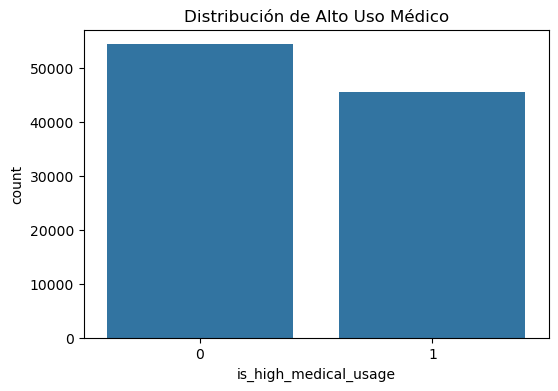

In [6]:
# Distribución de alto uso médico
plt.figure(figsize=(6, 4))
sns.countplot(x='is_high_medical_usage', data=health_insurance_df)
plt.title('Distribución de Alto Uso Médico')
plt.show()

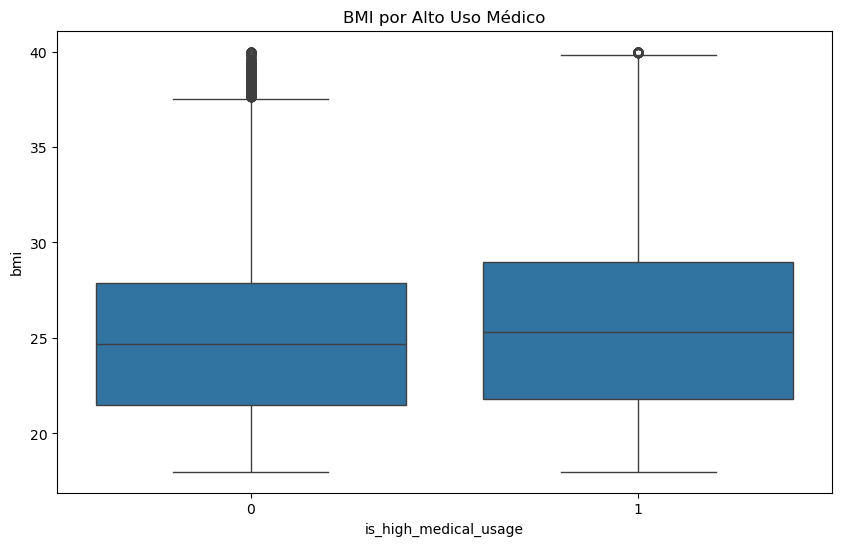

In [7]:
# BMI por alto uso
plt.figure(figsize=(10, 6))
sns.boxplot(x='is_high_medical_usage', y='bmi', data=health_insurance_df)
plt.title('BMI por Alto Uso Médico')
plt.show()

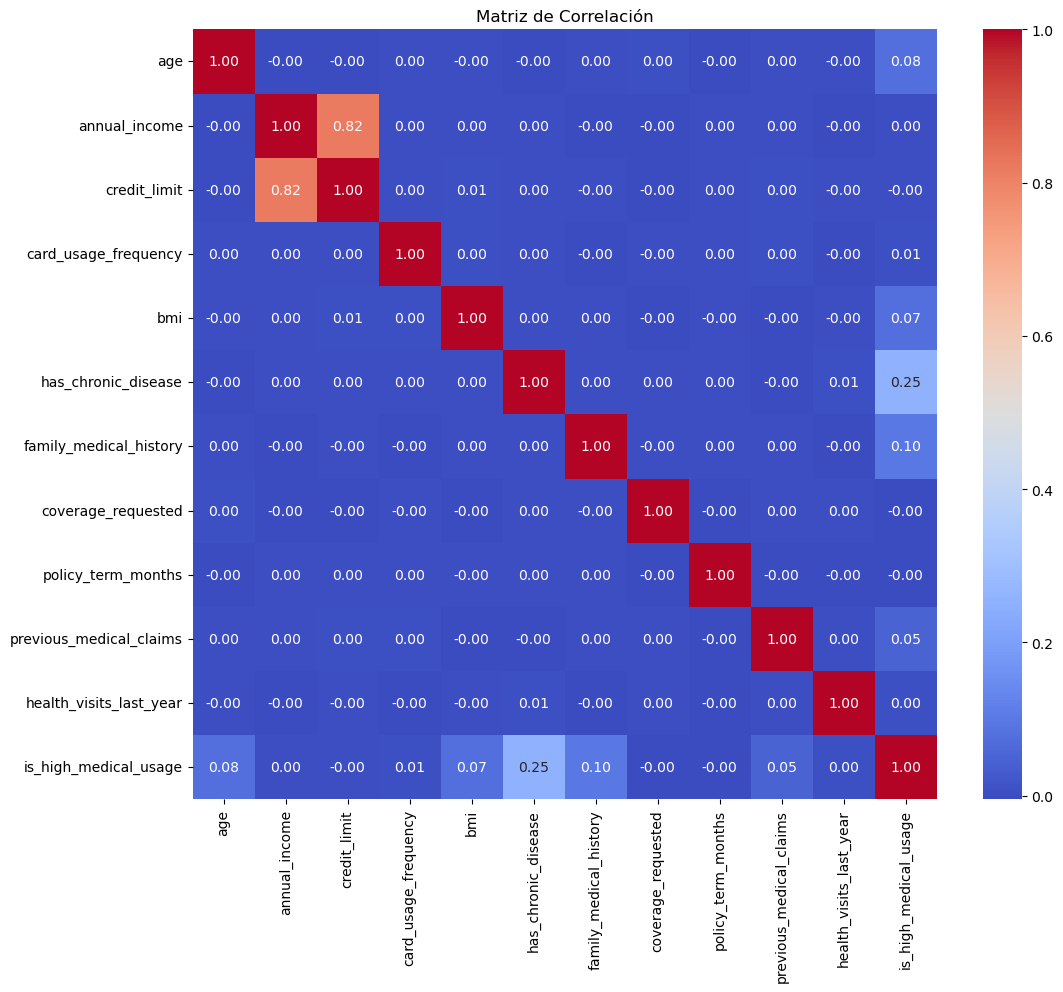

In [8]:
# Correlación numérica
numeric_cols = health_insurance_df.select_dtypes(include=[np.number]).columns
corr_matrix = health_insurance_df[numeric_cols].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación')
plt.show()

In [9]:
# Paso 3: Preprocesamiento para Random Forest
# Codificar categóricas
cat_cols = ['gender', 'smoking_status', 'occupation_risk_level', 'location_risk', 'policy_type_requested']
le_dict = {col: LabelEncoder().fit(health_insurance_df[col]) for col in cat_cols}
for col in cat_cols:
    health_insurance_df[col] = le_dict[col].transform(health_insurance_df[col])

In [10]:
# Escalar numéricas (opcional para RF, pero para consistencia)
num_cols = ['age', 'annual_income', 'credit_limit', 'card_usage_frequency', 'bmi', 'coverage_requested', 'health_visits_last_year']
scaler = StandardScaler()
health_insurance_df[num_cols] = scaler.fit_transform(health_insurance_df[num_cols])

In [11]:
# Dividir train/test (estratificado por alto uso)
X = health_insurance_df.drop(columns=['client_id', 'ds', 'is_high_medical_usage'])
y = health_insurance_df['is_high_medical_usage']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [16]:
# Paso 4: Definir y Entrenar Random Forest
# Random Forest: Ensemble de árboles (bagging + feature randomness), robusto, maneja no-linealidades y features mixtas
rf_model = RandomForestClassifier(
    n_estimators = 800,
    max_depth = 3,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'  # Para desbalance (alto uso raro)
)

rf_model

RandomForestClassifier(class_weight='balanced', max_depth=3, n_estimators=800,
                       n_jobs=-1, random_state=42)

In [17]:
rf_model.fit(X_train, y_train)

print("Modelo Random Forest entrenado.")

Modelo Random Forest entrenado.


In [18]:
# Paso 5: Evaluación del Modelo
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

In [19]:
# Reporte y métricas
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))


Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.69      0.65      0.67     10876
           1       0.61      0.65      0.63      9124

    accuracy                           0.65     20000
   macro avg       0.65      0.65      0.65     20000
weighted avg       0.65      0.65      0.65     20000



In [20]:
roc_auc = roc_auc_score(y_test, y_prob)
precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")

ROC-AUC: 0.7082
PR-AUC: 0.6592


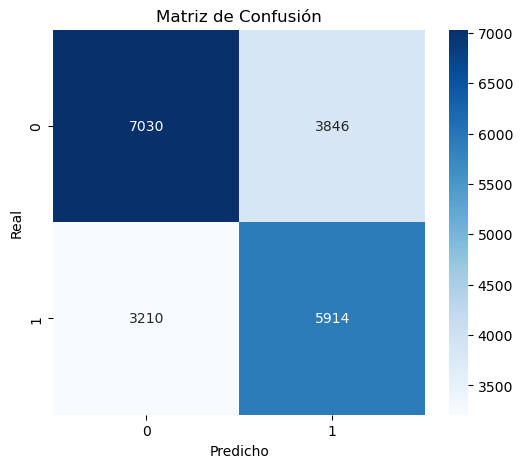

In [21]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()


Distribución de Riesgo en Test Set:
Riesgo
Medio Riesgo    0.9942
Alto Riesgo     0.0058
Bajo Riesgo     0.0000
Name: proportion, dtype: float64


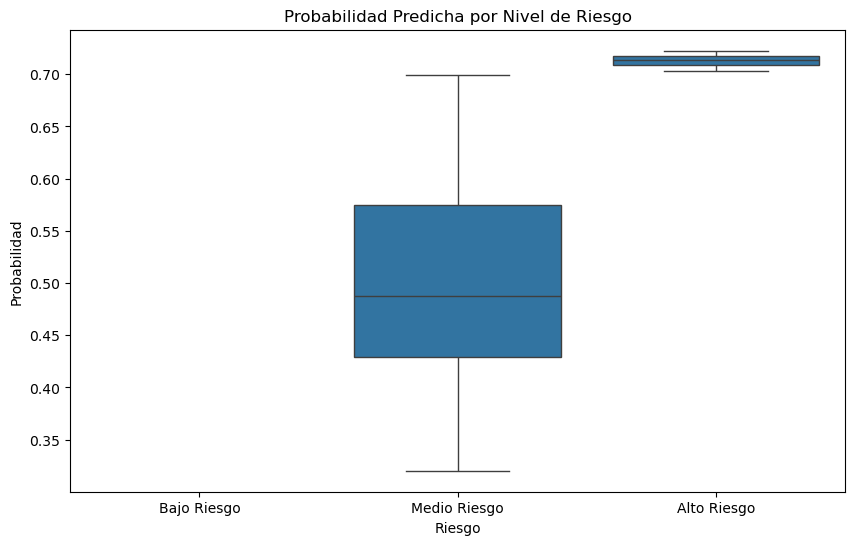

In [22]:
# Paso 6: Sección para Medir el Riesgo de Uso Médico Alto
# Riesgo: Basado en probabilidad (bajo <30%, medio 30-70%, alto >70%)
risk_levels = pd.cut(y_prob, bins=[0, 0.3, 0.7, 1.0], labels=['Bajo Riesgo', 'Medio Riesgo', 'Alto Riesgo'])
risk_df = pd.DataFrame({'Probabilidad': y_prob, 'Riesgo': risk_levels, 'Real Alto Uso': y_test})
print("\nDistribución de Riesgo en Test Set:")
print(risk_df['Riesgo'].value_counts(normalize=True))

# Visualizar riesgo
plt.figure(figsize=(10, 6))
sns.boxplot(x='Riesgo', y='Probabilidad', data=risk_df)
plt.title('Probabilidad Predicha por Nivel de Riesgo')
plt.show()

In [23]:
# Paso 7: Sección de Predicción con Perfil del Cliente
# Ejemplo: Predicción para un cliente nuevo, mostrar perfil, tipo de seguro, plazo y probabilidad
example_input_raw = {
    'age': 50,
    'gender': 'male',
    'annual_income': 70000,
    'credit_limit': 20000,
    'card_usage_frequency': 30,
    'bmi': 32,
    'smoking_status': 'yes',
    'has_chronic_disease': 1,
    'family_medical_history': 1,
    'occupation_risk_level': 'medium',
    'location_risk': 'urban',
    'policy_type_requested': 'premium',
    'coverage_requested': 50000,
    'policy_term_months': 24,
    'previous_medical_claims': 1,
    'health_visits_last_year': 10
}

# Preprocesar ejemplo
example_df = pd.DataFrame([example_input_raw])
for col in le_dict:
    if col in example_df.columns:
        example_df[col] = le_dict[col].transform([example_df[col][0]])
example_df[num_cols] = scaler.transform(example_df[num_cols])
example_df = example_df.reindex(columns=X.columns, fill_value=0)

pred_prob = rf_model.predict_proba(example_df)[0][1]

print("\n--- Predicción para Cliente Ejemplo ---")
print("Perfil del Cliente:")
print(f"- Edad: {example_input_raw['age']}")
print(f"- Género: {example_input_raw['gender']}")
print(f"- Ingreso Anual: ${example_input_raw['annual_income']}")
print(f"- BMI: {example_input_raw['bmi']}")
print(f"- Fumador: {example_input_raw['smoking_status']}")
print(f"- Tipo de Seguro Solicitado: {example_input_raw['policy_type_requested']}")
print(f"- Plazo: {example_input_raw['policy_term_months']} meses")

print("\nResultados:")
print(f"Probabilidad de Alto Uso Médico: {pred_prob:.2%}")
risk_level = "Bajo" if pred_prob < 0.3 else "Medio" if pred_prob < 0.7 else "Alto"
print(f"Nivel de Riesgo: {risk_level}")

# Prima sugerida (ejemplo: prima alta si alto riesgo)
base_premium = 300
factor = 2 if risk_level == "Alto" else 1.5 if risk_level == "Medio" else 1
suggested_premium = base_premium * factor + pred_prob * example_input_raw['coverage_requested'] * 0.01
print(f"Prima Sugerida Mensual: ${suggested_premium:.2f}")


--- Predicción para Cliente Ejemplo ---
Perfil del Cliente:
- Edad: 50
- Género: male
- Ingreso Anual: $70000
- BMI: 32
- Fumador: yes
- Tipo de Seguro Solicitado: premium
- Plazo: 24 meses

Resultados:
Probabilidad de Alto Uso Médico: 68.81%
Nivel de Riesgo: Medio
Prima Sugerida Mensual: $794.07


In [26]:
# Paso 8: Implementar SHAP para Explicabilidad
# SHAP: Analiza contribuciones de features a predicciones (crucial para transparencia en seguros)
explainer = shap.TreeExplainer(rf_model)

# SHAP values en muestra de test
X_test_sample = X_test.sample(100)
shap_values = explainer.shap_values(X_test_sample)

# Resumen global (para clase 1: alto uso)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values[1], X_test_sample, plot_type="bar")
plt.title('Importancia Global de Features (SHAP - Alto Uso Médico)')
plt.show()

# Resumen detallado
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values[1], X_test_sample)
plt.title('Impacto Detallado de Features (SHAP)')
plt.show()

# Ejemplo individual (primera instancia)
shap.force_plot(explainer.expected_value[1], shap_values[1][0], X_test_sample.iloc[0])
plt.title('SHAP Force Plot para Cliente Ejemplo')
plt.show()

AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

<Figure size 1000x800 with 0 Axes>


Análisis de Sensibilidad: Features más sensibles (mayor cambio en probabilidad al perturbar)
                    Feature  Sensibilidad Promedio (Delta Prob)
8            smoking_status                            0.102017
4                       bmi                            0.000739
0                       age                            0.000513
5        coverage_requested                            0.000303
9     occupation_risk_level                            0.000185
7                    gender                            0.000135
10            location_risk                            0.000108
11    policy_type_requested                            0.000107
1             annual_income                            0.000101
2              credit_limit                            0.000093
6   health_visits_last_year                            0.000037
3      card_usage_frequency                            0.000031


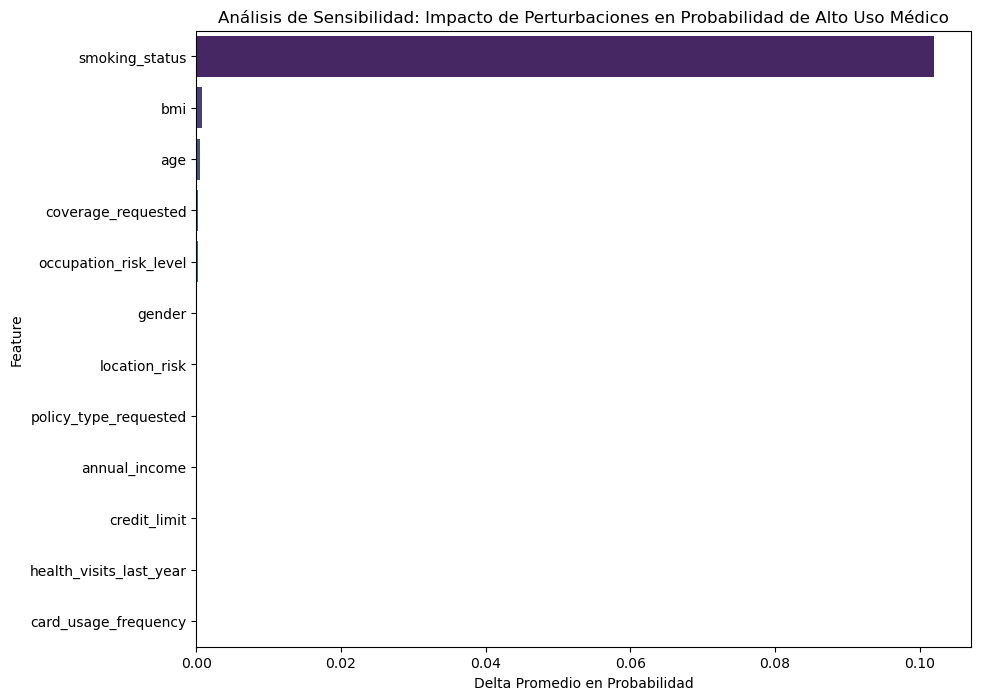


¡Ejemplo end-to-end completado con riesgo, SHAP y análisis de sensibilidad! Random Forest detecta alto uso médico para oferta de seguros de salud vinculados a tarjeta.
- Riesgo: Categoriza probabilidad para ofertas personalizadas (alto riesgo = prima alta o cobertura extendida).
- SHAP: Explica por qué (e.g., alto BMI aumenta riesgo).
- Sensibilidad: Evalúa impacto de cambios en inputs (útil para 'what-if' en ventas).
- Recomendación: En producción, integra con CRM bancario; usa probabilidades para scoring dinámico.


In [25]:


# Paso 9: Análisis de Sensibilidad
# Análisis de sensibilidad: Evalúa cómo cambia la predicción al variar cada feature (±10% para numéricas, cambio de categoría para categóricas)
# Útil para entender robustez del modelo y riesgos (e.g., cuánto aumenta la probabilidad si BMI sube 10%)
sensitivity_sample = X_test.sample(200)  # Muestra para eficiencia
base_pred = rf_model.predict_proba(sensitivity_sample)[:, 1]

sensitivity_results = []

# Perturbación numérica: ±10%
num_features = ['age', 'annual_income', 'credit_limit', 'card_usage_frequency', 'bmi', 'coverage_requested', 'health_visits_last_year']
for feat in num_features:
    delta_plus = sensitivity_sample.copy()
    delta_plus[feat] *= 1.1  # +10%
    pred_plus = rf_model.predict_proba(delta_plus)[:, 1]
    
    delta_minus = sensitivity_sample.copy()
    delta_minus[feat] *= 0.9  # -10%
    pred_minus = rf_model.predict_proba(delta_minus)[:, 1]
    
    avg_delta = np.mean(np.abs(pred_plus - base_pred) + np.abs(pred_minus - base_pred)) / 2
    sensitivity_results.append({'Feature': feat, 'Sensibilidad Promedio (Delta Prob)': avg_delta})

# Perturbación categórica: Cambiar a otra categoría aleatoria
cat_features = ['gender', 'smoking_status', 'occupation_risk_level', 'location_risk', 'policy_type_requested']
for feat in cat_features:
    perturbed = sensitivity_sample.copy()
    unique_vals = health_insurance_df[feat].unique()
    perturbed[feat] = perturbed[feat].apply(lambda x: np.random.choice([v for v in unique_vals if v != x]))
    pred_perturbed = rf_model.predict_proba(perturbed)[:, 1]
    
    avg_delta = np.mean(np.abs(pred_perturbed - base_pred))
    sensitivity_results.append({'Feature': feat, 'Sensibilidad Promedio (Delta Prob)': avg_delta})

sensitivity_df = pd.DataFrame(sensitivity_results).sort_values(by='Sensibilidad Promedio (Delta Prob)', ascending=False)

print("\nAnálisis de Sensibilidad: Features más sensibles (mayor cambio en probabilidad al perturbar)")
print(sensitivity_df)

# Visualizar sensibilidad (tornado plot)
plt.figure(figsize=(10, 8))
sns.barplot(x='Sensibilidad Promedio (Delta Prob)', y='Feature', data=sensitivity_df, palette='viridis')
plt.title('Análisis de Sensibilidad: Impacto de Perturbaciones en Probabilidad de Alto Uso Médico')
plt.xlabel('Delta Promedio en Probabilidad')
plt.show()

print("\n¡Ejemplo end-to-end completado con riesgo, SHAP y análisis de sensibilidad! Random Forest detecta alto uso médico para oferta de seguros de salud vinculados a tarjeta.")
print("- Riesgo: Categoriza probabilidad para ofertas personalizadas (alto riesgo = prima alta o cobertura extendida).")
print("- SHAP: Explica por qué (e.g., alto BMI aumenta riesgo).")
print("- Sensibilidad: Evalúa impacto de cambios en inputs (útil para 'what-if' en ventas).")
print("- Recomendación: En producción, integra con CRM bancario; usa probabilidades para scoring dinámico.")